# Máquinas Térmicas - Lección 8
## Cinética de la Combustión

**Autor:** Camilo Bayona
**Fecha:** 12/08/2025

*Continuación de las Lecciones 6 y 7: la Lección 6 dio la **ley de velocidad** y Arrhenius para una especie; la Lección 7 dio los **totales** de masa y energía. Aquí acoplamos varias especies con **ecuaciones diferenciales** para ver la combustión evolucionar en el tiempo.*

### Objetivos de aprendizaje
1. Formular sistemas de **EDOs acopladas** para las concentraciones usando la ley de acción de masas (términos producto entre concentraciones).
2. Explicar el modelo **SIR**, los fenómenos de sus compartimentos (contagio, recuperación) y su analogía exacta con la cinética química.
3. Simular la combustión de H$_2$, C, S y de un hidrocarburo genérico $C_xH_y$ con O$_2$ puro y con aire, verificando conservación de átomos y reactivo límite.
4. Acoplar la **liberación de calor** $\dot{q}(t)$ al balance de energía y explicar la **ignición térmica** (realimentación de Arrhenius).

In [1]:
# Instalación solo en Google Colab; en el entorno local del curso es un no-op
import sys
if "google.colab" in sys.modules:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "matplotlib", "ipywidgets", "numpy", "scipy"], check=True)

In [2]:
# === Setup =================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from ipywidgets import (interact, interactive_output, FloatSlider, IntSlider,
                        Dropdown, Checkbox, Play, HBox, VBox, jslink)
from IPython.display import display

R = 8.314  # J/(mol·K)
# Paleta fija de especies (idéntica en las Lecciones 7, 8 y 8b)
COL = {"fuel": "#2a78d6", "O2": "#e34948", "H2O": "#1baf7a", "CO2": "#eda100",
       "SO2": "#4a3aa7", "NOx": "#eb6834", "N2": "#8a8a86", "tinta": "#3a3a38"}
# En el SIR usamos la misma correspondencia: S≡combustible (azul), I≡O2 (rojo), R≡producto (verde-agua)
print("Setup OK")

Setup OK


## 1. Velocidad de reacción

La velocidad de reacción está conformada por la velocidad de formación y la velocidad de descomposición. Esta velocidad no es constante y depende de varios factores, como la concentración de los reactivos, la presencia de un catalizador, la temperatura de reacción y el estado físico de los reactivos.

Uno de los factores más importantes es la concentración de los reactivos. Cuanto más partículas existan en un volumen, más colisiones hay entre las partículas por unidad de tiempo. Al principio, cuando la concentración de reactivos es mayor, también es mayor la probabilidad de que se den colisiones entre las moléculas, y la velocidad es mayor. A medida que la reacción avanza, al ir disminuyendo la concentración de los reactivos, disminuye la probabilidad de colisión y con ella la velocidad de la reacción. La medida de la rapidez de reacción implica la medida de la concentración de uno de los reactivos o productos a lo largo del tiempo, esto es, para medir la velocidad de una reacción necesitamos medir, bien la cantidad de reactivo que desaparece por unidad de tiempo, o bien la cantidad de producto que aparece por unidad de tiempo. La velocidad de reacción se mide en unidades de concentración/tiempo, esto es, en (mol/L)/s, es decir, mol/(L·s).

Para una reacción de la forma:

$$\mathrm{A \ \longrightarrow \ B + C}$$

la ley de la velocidad de formación es la siguiente:

$$v_{\mathrm r} = - \frac{\mathrm{d} c_{\mathrm{A}}}{\mathrm{d}t}$$

$v_{\mathrm r}$ es la velocidad de la reacción, $(- \mathrm{d}c_{\mathrm{A}})$ la disminución de la concentración del reactivo $\rm A$ en un tiempo $\mathrm{d}t$. Esta velocidad es la velocidad media de la reacción, pues todas las moléculas necesitan tiempos distintos para reaccionar.

La velocidad de aparición del producto es igual a la velocidad de desaparición del reactivo. De este modo, la ley de la velocidad se puede escribir de la siguiente forma:

$$v_{\mathrm r} = - \frac{\mathrm{d}c_{\mathrm{A}}}{\mathrm{d}t} = \frac{\mathrm{d}c_{\mathrm{B}}}{\mathrm{d}t} = \frac{\mathrm{d}c_{\mathrm{C}}}{\mathrm{d}t}$$

Este modelo necesita otras simplificaciones con respecto a:

* la actividad química, es decir, la "concentración efectiva"
* la cantidad de los reactivos en proporción a la cantidad de los productos y del disolvente
* la temperatura
* la energía de colisión
* presencia de catalizadores
* la presión parcial de gases

Para una reacción hipotética de la forma:

$$a\mathrm{A} + b\mathrm{B} \longrightarrow g\mathrm{G} + h\mathrm{H}$$

La velocidad de reacción se define como la siguiente expresión en caso de que sea una reacción simple molecular, como la del caso anterior:

$$ v=k\mathrm{[A]}^\alpha\mathrm{[B]}^\beta$$

las concentraciones de reactivos están elevadas a su correspondiente coeficiente cinético sólo en el caso en el que la reacción sea elemental. Donde los corchetes denotan la concentración de cada una de las especies; $v$ denota la velocidad de reacción y $k$ es la constante cinética.
La velocidad de las reacciones químicas abarca escalas de tiempo muy amplias. Por ejemplo, una explosión puede ocurrir en menos de un segundo; la cocción de un alimento puede tardar minutos u horas.

Entre los varios factores que afectan la velocidad de una reacción química: la concentración de los reactivos, el grado de división, la temperatura, la existencia de catalizadores y la superficie de contactos tanto de los reactivos como del catalizador, una muy importante es la Temperatura de la reacción. Los catalizadores también pueden aumentar o disminuir la velocidad de reacción.

*(En la Lección 6 estudiamos estas leyes para una sola especie — órdenes 0, 1 y 2, vida media, Arrhenius. Aquí las acoplamos entre varias especies.)*

### 1.1 Reacción en función de la temperatura

Por norma general, la velocidad de reacción aumenta con la temperatura porque incrementa la energía cinética de las moléculas. Con mayor energía cinética, las moléculas se mueven más rápido y chocan con más frecuencia y con más energía. El comportamiento de la constante de velocidad frente a la temperatura se describe a través de la ecuación de Arrhenius:

$$k = A\,\mathrm{e}^{-E_{\rm a}/RT}$$

donde $k$ es la constante de rapidez, $A$ es el factor de frecuencia, $E_{\rm a}$ es la energía de activación necesaria y $T$ es la temperatura absoluta.

Al linealizarla se obtiene que el logaritmo neperiano de la constante de rapidez es una recta frente al inverso de la temperatura, $\ln k = \ln A - \dfrac{E_a}{R}\,\dfrac{1}{T}$, y comparando dos temperaturas:

$$\ln\left(\frac{k_2}{k_1}\right) = -\frac{E_a}{R}\left(\frac{1}{T_2} - \frac{1}{T_1}\right)$$

Esta forma linealizada es muy útil a la hora de calcular la energía de activación experimentalmente, ya que la pendiente de la recta obtenida al graficar $\ln k$ contra $1/T$ es $-\frac{E_a}{R}$; haciendo un simple despeje se obtiene fácilmente esta energía de activación, tomando en cuenta que el valor de la constante universal de los gases es $R = 8.314$ J/(mol·K). Para un buen número de reacciones químicas la rapidez se duplica aproximadamente cada diez grados centígrados.

## 2. El modelo epidémico SIR (Kermack–McKendrick)

Una descripción matemática simple de la propagación de una enfermedad en una población es el llamado modelo SIR, que divide la población (fija) de $N$ individuos en tres "compartimentos" que pueden variar en función del tiempo, $t$:

- $S(t)$ son aquellos susceptibles pero aún no infectados con la enfermedad.
- $I(t)$ es el número de individuos infecciosos.
- $R(t)$ son aquellos individuos que se han recuperado de la enfermedad y ahora tienen inmunidad a ella.

El modelo SIR describe el cambio en la población de cada uno de estos compartimentos en términos de dos parámetros, $\beta$ y $\gamma$. $\beta$ describe la *tasa de contacto* efectiva de la enfermedad: un individuo infectado entra en contacto con $\beta N$ otros individuos por unidad de tiempo (de los cuales la fracción que son susceptibles a contraer la enfermedad es $S/N$). $\gamma$ es la tasa media de recuperación: es decir, $1/\gamma$ es el período medio de tiempo durante el cual un individuo infectado puede transmitirlo.

Las ecuaciones diferenciales que describen este modelo fueron derivadas por primera vez por Kermack y McKendrick [*Proc. R. Soc. A*, **115**, 772 (1927)]:

$$\begin{aligned}
\frac{\mathrm{d}S}{\mathrm{d}t} &= -\frac{\beta S I}{N},\\
\frac{\mathrm{d}I}{\mathrm{d}t} &= \frac{\beta S I}{N} - \gamma I,\\
\frac{\mathrm{d}R}{\mathrm{d}t} &= \gamma I.
\end{aligned}$$

*(Nota: este modelo es pariente del modelo depredador–presa de **Lotka–Volterra** — ambos comparten el término bilineal de "encuentro" entre dos poblaciones, que es exactamente lo que explotaremos como analogía química.)*

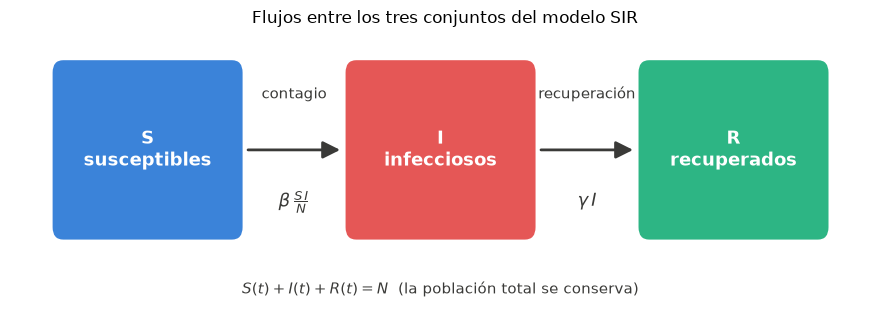

In [3]:
# Diagrama de compartimentos del modelo SIR — generado por código
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(9, 3.4))
cajas = [(0.6, "S\nsusceptibles", COL["fuel"]), (3.9, "I\ninfecciosos", COL["O2"]),
         (7.2, "R\nrecuperados", COL["H2O"])]
for x, txt, c in cajas:
    ax.add_patch(FancyBboxPatch((x, 0.9), 1.9, 1.5, boxstyle="round,pad=0.12",
                                fc=c, ec="none", alpha=0.92))
    ax.text(x + 0.95, 1.65, txt, ha="center", va="center", fontsize=13,
            color="white", fontweight="bold")
for x0 in (2.65, 5.95):
    ax.add_patch(FancyArrowPatch((x0, 1.65), (x0 + 1.1, 1.65),
                                 arrowstyle="-|>", mutation_scale=26, color=COL["tinta"], lw=2))
ax.text(3.2, 2.15, r"contagio", ha="center", fontsize=11, color=COL["tinta"])
ax.text(3.2, 1.1, r"$\beta\,\frac{S\,I}{N}$", ha="center", fontsize=13, color=COL["tinta"])
ax.text(6.5, 2.15, r"recuperación", ha="center", fontsize=11, color=COL["tinta"])
ax.text(6.5, 1.1, r"$\gamma\,I$", ha="center", fontsize=13, color=COL["tinta"])
ax.text(4.85, 0.25, r"$S(t) + I(t) + R(t) = N$  (la población total se conserva)",
        ha="center", fontsize=11, color=COL["tinta"])
ax.set_xlim(0, 9.8); ax.set_ylim(0, 2.8); ax.axis("off")
ax.set_title("Flujos entre los tres conjuntos del modelo SIR")
plt.tight_layout(); plt.show()

### 2.1 Los fenómenos detrás de cada término: productos entre concentraciones

Cada término de las EDOs corresponde a un **fenómeno físico**, y su forma matemática lo delata:

- **Contagio** $-\beta S I/N$: para que un susceptible se infecte necesita un **encuentro** con un infeccioso. El número de encuentros por unidad de tiempo es proporcional al **producto** de ambas poblaciones, $S \times I$: si duplico los infecciosos *o* los susceptibles, duplico los contagios; si no queda ninguno de los dos, el término se apaga solo. El signo es **negativo** en la ecuación de $S$ (ese conjunto pierde miembros) y **positivo** en la de $I$ (los recibe).
- **Recuperación** $+\gamma I$: cada infeccioso se recupera solo, sin necesitar encuentro alguno: el flujo es **lineal** en $I$ (una fracción fija $\gamma$ del conjunto por unidad de tiempo).
- **Conservación**: sumando las tres ecuaciones, $\frac{d}{dt}(S+I+R)=0$ — nadie entra ni sale de la población.

La cinética química usa **exactamente la misma gramática** (ley de acción de masas):

| Fenómeno SIR | Término | Fenómeno químico | Término |
|---|---|---|---|
| contagio (encuentro S–I) | $\pm\beta\, S I/N$ | **colisión bimolecular** A + B → productos | $\pm k\,[A][B]$ |
| recuperación (espontánea, individual) | $\pm\gamma\, I$ | **descomposición unimolecular** (1er orden) | $\pm k_1\,[A]$ |
| población constante $S+I+R=N$ | suma $=0$ | **conservación de átomos** | $\mathbf{E}\,\boldsymbol{\nu}=\mathbf{0}$ |

Un término **producto de concentraciones** siempre está contando **encuentros/colisiones**; un término **lineal** siempre cuenta eventos **espontáneos**. Los signos dicen qué conjunto pierde (−) y cuál gana (+).

El siguiente widget integra estas ecuaciones para una enfermedad caracterizada por los parámetros $\beta = 0.2$, $1/\gamma = 10\ \mathrm{días}$ en una población de $N=1000$ (quizás el COVID en un curso universitario). El modelo se inicia con un solo individuo infectado en el día 0: $I(0)=1$. Además de las curvas $S(t)$, $I(t)$ y $R(t)$, el panel izquierdo muestra la **dinámica de los conjuntos**: cada punto es un individuo que cambia de color al contagiarse y al recuperarse — presiona ▶ para animar el tiempo.

In [4]:
# WIDGET 1 — SIR interactivo con animación de la dinámica de los conjuntos
N_PUNTOS = 400                      # individuos dibujados (muestra representativa de N)
rng = np.random.default_rng(7)
_gx, _gy = np.meshgrid(np.arange(20), np.arange(20))
POS = np.c_[_gx.ravel() + rng.uniform(-0.3, 0.3, N_PUNTOS),
            _gy.ravel() + rng.uniform(-0.3, 0.3, N_PUNTOS)]
ORDEN = rng.permutation(N_PUNTOS)   # orden fijo de contagio y de recuperación

def sir_sol(beta, gamma, N, I0, t):
    def deriv(y, t):
        S, I, Rr = y
        return -beta*S*I/N, beta*S*I/N - gamma*I, gamma*I
    return odeint(deriv, [N - I0, I0, 0.0], t).T

def dibuja_sir(beta=0.2, dias_rec=10.0, I0=1, dia=60):
    N, gamma = 1000.0, 1.0/dias_rec
    t = np.linspace(0, 160, 321)
    S, I, Rr = sir_sol(beta, gamma, N, I0, t)
    i_now = np.searchsorted(t, dia)
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.6),
                                   gridspec_kw={"width_ratios": [1, 1.5]})
    # --- panel izquierdo: los conjuntos como puntos ---
    n_R = int(round(Rr[i_now] / N * N_PUNTOS))
    n_I = int(round(I[i_now] / N * N_PUNTOS))
    colores = np.full(N_PUNTOS, COL["fuel"], dtype=object)     # S azules
    colores[ORDEN[:n_R]] = COL["H2O"]                          # recuperados (primeros contagiados)
    colores[ORDEN[n_R:n_R + n_I]] = COL["O2"]                  # infecciosos actuales
    ax0.scatter(POS[:, 0], POS[:, 1], c=list(colores), s=26)
    ax0.set_title(f"día {t[i_now]:.0f}:  S={S[i_now]:.0f}  I={I[i_now]:.0f}  R={Rr[i_now]:.0f}")
    ax0.set_aspect("equal"); ax0.axis("off")
    # --- panel derecho: curvas con cursor temporal ---
    ax1.plot(t, S, color=COL["fuel"], lw=2.2, label="S susceptibles")
    ax1.plot(t, I, color=COL["O2"], lw=2.2, label="I infecciosos")
    ax1.plot(t, Rr, color=COL["H2O"], lw=2.2, label="R recuperados")
    ax1.axvline(t[i_now], color=COL["tinta"], lw=1.0, ls=":")
    for serie, c in [(S, COL["fuel"]), (I, COL["O2"]), (Rr, COL["H2O"])]:
        ax1.plot(t[i_now], serie[i_now], "o", ms=7, color=c, mec="white", mew=1.2)
    R0 = beta / gamma
    pico = t[np.argmax(I)]
    ax1.set_title(f"$R_0=\\beta/\\gamma$ = {R0:.2f} | pico de I en el día {pico:.0f} | "
                  f"tamaño final R(∞) ≈ {Rr[-1]:.0f}")
    ax1.set_xlabel("tiempo [días]"); ax1.set_ylabel("individuos")
    ax1.legend(); ax1.grid(alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

play = Play(value=60, min=0, max=160, step=2, interval=110)
dia_sl = IntSlider(60, min=0, max=160, description="día")
jslink((play, "value"), (dia_sl, "value"))
beta_sl = FloatSlider(0.2, min=0.05, max=1.0, step=0.01, description="β [1/día]")
rec_sl = FloatSlider(10.0, min=2, max=30, step=1, description="1/γ [días]")
I0_sl = IntSlider(1, min=1, max=50, description="I(0)")
salida = interactive_output(dibuja_sir, {"beta": beta_sl, "dias_rec": rec_sl,
                                         "I0": I0_sl, "dia": dia_sl})
display(VBox([HBox([play, dia_sl]), HBox([beta_sl, rec_sl, I0_sl]), salida]))

**Explora con el widget:** con $R_0 = \beta/\gamma < 1$ la epidemia se apaga (cada infeccioso no alcanza a reemplazarse); con $R_0 > 1$ hay brote. Nota que la epidemia termina **sin agotar los susceptibles**: cuando $S/N < 1/R_0$ el término de contagio ya no compensa la recuperación. En la química ocurrirá distinto: la "epidemia" (reacción) continúa hasta agotar el **reactivo límite**.

## 3. Cinética de la Oxidación del Hidrógeno

La reacción de oxidación del hidrógeno es una reacción química fundamental en la combustión. La reacción es la siguiente:

$$2H_2 + O_2 \rightarrow 2H_2O$$

### 3.1 La analogía SIR literal (y su problema)

Ahora vamos a modelar la cinética de la reacción de oxidación del hidrógeno utilizando un modelo SIR. En este modelo, las cantidades S, I y R representarán las concentraciones de H2, O2 y H2O, respectivamente. Las ecuaciones diferenciales del modelo SIR trasladadas literalmente son las siguientes:

$$\frac{d[H_2]}{dt} = -\beta \cdot \frac{[H_2] \cdot [O_2]}{N}, \qquad
\frac{d[O_2]}{dt} = \beta \cdot \frac{[H_2] \cdot [O_2]}{N} - \gamma \cdot [O_2], \qquad
\frac{d[H_2O]}{dt} = \gamma \cdot [O_2]$$

donde $\beta$ es la tasa de reacción entre H2 y O2, $\gamma$ es la tasa de formación de H2O y N es la concentración total de moléculas.

**⚠ El problema: los átomos no se conservan.** La analogía captura la *forma* de los términos (producto = colisión, lineal = espontáneo), pero trasladada literalmente **viola la conservación de la masa**: el término $\gamma[O_2]$ crea H$_2$O "espontáneamente" sin consumir H$_2$, y el O$_2$ *gana* moléculas con las colisiones ($+\beta[H_2][O_2]/N$) en vez de perderlas. En una epidemia los individuos *cambian de conjunto* (S→I→R); en una reacción los átomos *se recombinan* según la estequiometría.

### 3.2 El modelo químico consistente

La ley de acción de masas con la estequiometría $2H_2 + O_2 \rightarrow 2H_2O$ corrige ambos defectos. Definimos **una** velocidad de reacción por colisión H$_2$–O$_2$:

$$r = k\,[H_2][O_2]$$

y cada especie evoluciona con **su coeficiente estequiométrico** multiplicando a $r$:

$$\frac{d[H_2]}{dt} = -2r, \qquad \frac{d[O_2]}{dt} = -r, \qquad \frac{d[H_2O]}{dt} = +2r$$

Ahora los átomos se conservan exactamente: $\frac{d}{dt}\big(2[H_2] + 2[H_2O]\big) = 0$ (átomos de H) y $\frac{d}{dt}\big(2[O_2] + [H_2O]\big) = 0$ (átomos de O). La reacción avanza hasta agotar el **reactivo límite**. *(Usamos orden 1 en cada reactivo por simplicidad; la cinética real del H$_2$/O$_2$ es una cadena ramificada con decenas de reacciones elementales.)*

El widget siguiente resuelve **ambos** modelos y grafica, además de las concentraciones, el inventario de átomos de H y O: la línea debe ser horizontal si el modelo es físicamente consistente.

In [5]:
# WIDGET 2 — H2 + O2: analogía SIR literal vs modelo químico consistente
def h2_o2(modelo="químico (conserva átomos)", k=0.02, x_H2=0.7, t_fin=40.0):
    C_tot = 10.0                                   # concentración total inicial [mol/m³]
    H2_0, O2_0 = x_H2 * C_tot, (1 - x_H2) * C_tot
    t = np.linspace(0, t_fin, 600)
    if modelo.startswith("SIR"):
        beta, gamma = k * C_tot, k * C_tot * 0.5   # escala comparable
        def deriv(y, t):
            H2, O2, H2O = y
            return (-beta*H2*O2/C_tot, beta*H2*O2/C_tot - gamma*O2, gamma*O2)
    else:
        def deriv(y, t):
            H2, O2, H2O = y
            r = k * H2 * O2
            return (-2*r, -r, 2*r)
    H2, O2, H2O = odeint(deriv, [H2_0, O2_0, 0.0], t).T
    atomos_H, atomos_O = 2*H2 + 2*H2O, 2*O2 + H2O
    lim = "H2" if H2_0/2 < O2_0 else "O2"          # reactivo límite estequiométrico
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8.5, 6.8), sharex=True,
                                   gridspec_kw={"height_ratios": [2.2, 1]})
    ax0.plot(t, H2, color=COL["fuel"], lw=2.4, label="[H$_2$]")
    ax0.plot(t, O2, color=COL["O2"], lw=2.4, label="[O$_2$]")
    ax0.plot(t, H2O, color=COL["H2O"], lw=2.4, label="[H$_2$O]")
    ax0.set_ylabel("concentración [mol/m³]")
    ax0.set_title(f"{modelo} — mezcla {x_H2:.0%} H$_2$ | reactivo límite: {lim}")
    ax0.legend(); ax0.grid(alpha=0.25); ax0.spines[["top", "right"]].set_visible(False)
    ax1.plot(t, atomos_H, color=COL["tinta"], lw=2.2, label="átomos de H")
    ax1.plot(t, atomos_O, color=COL["N2"], lw=2.2, ls="--", label="átomos de O")
    drift_H = abs(atomos_H[-1] - atomos_H[0]) / atomos_H[0] * 100
    drift_O = abs(atomos_O[-1] - atomos_O[0]) / atomos_O[0] * 100
    veredicto = "✔ conservados" if max(drift_H, drift_O) < 0.01 else "✘ NO conservados"
    ax1.set_title(f"inventario de átomos: {veredicto} (deriva H {drift_H:.1f} %, O {drift_O:.1f} %)",
                  fontsize=10)
    ax1.set_xlabel("tiempo [s]"); ax1.set_ylabel("mol de átomos/m³")
    ax1.legend(loc="center right"); ax1.grid(alpha=0.25)
    ax1.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(h2_o2,
         modelo=Dropdown(options=["químico (conserva átomos)", "SIR literal (analogía)"],
                         description="modelo"),
         k=FloatSlider(0.02, min=0.002, max=0.1, step=0.002, description="k [m³/mol·s]",
                       readout_format=".3f"),
         x_H2=FloatSlider(0.7, min=0.1, max=0.9, step=0.05, description="fracción H₂"),
         t_fin=FloatSlider(40, min=5, max=200, step=5, description="t final [s]"));

interactive(children=(Dropdown(description='modelo', options=('químico (conserva átomos)', 'SIR literal (analo…

**Explora con el widget:** en el modelo químico, con la mezcla estequiométrica ($x_{H_2} = 2/3 \approx 0.67$) ambos reactivos se agotan juntos; con más H$_2$ sobra combustible y con menos sobra O$_2$. Cambia al modelo *SIR literal* y observa el panel de átomos: el inventario deriva — la analogía es pedagógica, no física.

## 4. Oxidación del Carbono y del Azufre

Ahora vamos a modelar la oxidación del carbono. La reacción es la siguiente:

$$C + O_2 \rightarrow CO_2$$

Finalmente, la oxidación del azufre:

$$S + O_2 \rightarrow SO_2$$

Ambas comparten la estequiometría 1:1:1, así que el **mismo** sistema de EDOs las describe con solo renombrar especies (¡la ventaja de haber generalizado!):

$$r = k\,[F][O_2], \qquad \frac{d[F]}{dt} = -r, \qquad \frac{d[O_2]}{dt} = -r, \qquad \frac{d[P]}{dt} = +r$$

con $F \in \{C, S\}$ y $P \in \{CO_2, SO_2\}$. *(El C y el S son sólidos: su combustión real es **heterogénea** — ocurre en la superficie de la partícula. El modelo homogéneo de arriba es la simplificación usual de los modelos 0D, la misma que emplea el artículo de biomasa de la Lección 8b.)*

En vez de copiar tres veces el código (H$_2$, C, S), lo escribimos **una vez** parametrizado por la estequiometría:

In [ ]:
# WIDGET 3 — simulador general de F + O2 para las tres reacciones de la lección
REACCIONES = {  # nombre: (nu_F, nu_O2, nu_P, etiqueta producto, color producto)
    "2H2 + O2 -> 2H2O": (2, 1, 2, "H$_2$O", COL["H2O"], "[H$_2$]"),
    "C + O2 -> CO2":    (1, 1, 1, "CO$_2$", COL["CO2"], "[C]"),
    "S + O2 -> SO2":    (1, 1, 1, "SO$_2$", COL["SO2"], "[S]"),
}

def simular_combustion(reaccion="C + O2 -> CO2", k=0.02, x_F=0.5, t_fin=60.0):
    nu_F, nu_O2, nu_P, nom_P, col_P, nom_F = REACCIONES[reaccion]
    C_tot = 10.0
    F0, O20 = x_F * C_tot, (1 - x_F) * C_tot
    t = np.linspace(0, t_fin, 600)
    def deriv(y, t):
        F, O2, P = y
        r = k * F * O2
        return (-nu_F*r, -nu_O2*r, nu_P*r)
    F, O2, P = odeint(deriv, [F0, O20, 0.0], t).T
    lim = nom_F if F0/nu_F < O20/nu_O2 else "[O$_2$]"
    fig, ax = plt.subplots(figsize=(8.5, 5))
    ax.plot(t, F, color=COL["fuel"], lw=2.4, label=nom_F)
    ax.plot(t, O2, color=COL["O2"], lw=2.4, label="[O$_2$]")
    ax.plot(t, P, color=col_P, lw=2.4, label=f"[{nom_P.strip('$')}]".replace("[", "[").replace("]", "]") if False else nom_P)
    ax.axhline(0, color=COL["tinta"], lw=0.6)
    ax.set_xlabel("tiempo [s]"); ax.set_ylabel("concentración [mol/m³]")
    ax.set_title(f"{reaccion}   |   reactivo límite: {lim}")
    ax.legend(); ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(simular_combustion,
         reaccion=Dropdown(options=list(REACCIONES), value="C + O2 -> CO2", description="reacción"),
         k=FloatSlider(0.02, min=0.002, max=0.1, step=0.002, description="k [m³/mol·s]",
                       readout_format=".3f"),
         x_F=FloatSlider(0.5, min=0.1, max=0.9, step=0.05, description="fracción comb."),
         t_fin=FloatSlider(60, min=5, max=300, step=5, description="t final [s]"));

interactive(children=(Dropdown(description='reacción', index=1, options=('2H2 + O2 -> 2H2O', 'C + O2 -> CO2', …

## 5. Cinética global de un hidrocarburo $C_xH_y$ con oxidante puro

El paso final de generalidad: cualquier hidrocarburo. Los mecanismos reales tienen cientos de reacciones elementales, pero para ingeniería térmica basta la **cinética global de un paso** (Westbrook & Dryer, 1981):

$$C_xH_y + \left(x + \frac{y}{4}\right) O_2 \;\longrightarrow\; x\,CO_2 + \frac{y}{2}\,H_2O,
\qquad r = k\,[C_xH_y][O_2], \qquad k = A\,e^{-E_a/RT}$$

Las EDOs acopladas siguen la regla estequiométrica de siempre:

$$\frac{d[F]}{dt} = -r, \quad \frac{d[O_2]}{dt} = -\left(x+\tfrac{y}{4}\right) r, \quad \frac{d[CO_2]}{dt} = +x\,r, \quad \frac{d[H_2O]}{dt} = +\tfrac{y}{2}\,r$$

**El aporte de energía en el tiempo** se acopla directamente a $r$: cada mol de combustible quemado libera $|\Delta H_c|$ (Lección 7, entalpías de formación), de modo que la potencia volumétrica y el calor acumulado son

$$\dot{q}(t) = r(t)\,|\Delta H_c| \ \left[\tfrac{kJ}{m^3 s}\right], \qquad Q(t) = \int_0^t \dot{q}\,dt'$$

La riqueza de la mezcla se controla con la **relación de equivalencia** $\phi = \dfrac{(F/O_2)}{(F/O_2)_{esteq}}$: $\phi=1$ estequiométrica, $\phi>1$ rica (sobra combustible), $\phi<1$ pobre (sobra O$_2$).

In [7]:
# WIDGET 4 — hidrocarburo genérico con O2: concentraciones + aporte de energía en el tiempo
Hf8 = {"CO2": -393.52, "H2O_g": -241.82, "CH4": -74.85, "C3H8": -103.85}  # kJ/mol (Lección 7)

def sim_hc(x, y, phi, k, con_aire, t_fin, C_tot=10.0):
    nu = x + y/4                                    # O2 estequiométrico
    # mezcla F : O2 : (N2) con relación de equivalencia phi y densidad molar total fija
    n_F, n_O2 = phi, nu                             # proporciones molares
    n_N2 = 3.76 * nu if con_aire else 0.0
    esc = C_tot / (n_F + n_O2 + n_N2)
    F0, O20, N20 = n_F*esc, n_O2*esc, n_N2*esc
    dHc = -(x*Hf8["CO2"] + (y/2)*Hf8["H2O_g"])      # |ΔHc| aprox (ΔHf comb ≈ 0) [kJ/mol]
    t = np.linspace(0, t_fin, 800)
    def deriv(yv, t):
        F, O2, CO2, H2O = yv
        r = k * F * O2
        return (-r, -nu*r, x*r, (y/2)*r)
    F, O2, CO2, H2O = odeint(deriv, [F0, O20, 0.0, 0.0], t).T
    qdot = k * F * O2 * dHc                         # kJ/(m³·s)
    Q = np.concatenate([[0.0], np.cumsum(np.diff(t) * 0.5 * (qdot[1:] + qdot[:-1]))])
    return t, F, O2, CO2, H2O, N20, qdot, Q

def hidrocarburo(x=3, y=8, phi=1.0, k=0.02, oxidante="O2 puro", t_fin=60.0):
    con_aire = oxidante == "aire (O2 + 3.76 N2)"
    t, F, O2, CO2, H2O, N20, qdot, Q = sim_hc(x, y, phi, k, con_aire, t_fin)
    fig, axs = plt.subplots(3, 1, figsize=(8.5, 8.6), sharex=True,
                            gridspec_kw={"height_ratios": [2, 1.2, 1.2]})
    ax = axs[0]
    ax.plot(t, F, color=COL["fuel"], lw=2.4, label=f"[C$_{{{x}}}$H$_{{{y}}}$]")
    ax.plot(t, O2, color=COL["O2"], lw=2.4, label="[O$_2$]")
    ax.plot(t, CO2, color=COL["CO2"], lw=2.4, label="[CO$_2$]")
    ax.plot(t, H2O, color=COL["H2O"], lw=2.4, label="[H$_2$O]")
    if N20 > 0:
        ax.axhline(N20, color=COL["N2"], lw=1.8, ls="--")
        ax.text(t[-1]*0.99, N20, "[N$_2$] inerte", ha="right", va="bottom",
                fontsize=9, color=COL["N2"])
    reg = "estequiométrica" if abs(phi-1) < 1e-9 else ("rica" if phi > 1 else "pobre")
    ax.set_ylabel("concentración [mol/m³]")
    ax.set_title(f"C$_{{{x}}}$H$_{{{y}}}$ + {oxidante} — mezcla {reg} (φ={phi:.2f})")
    ax.legend(ncol=2); ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    axs[1].plot(t, qdot, color=COL["NOx"], lw=2.4)
    axs[1].fill_between(t, qdot, color=COL["NOx"], alpha=0.15)
    axs[1].set_ylabel("$\\dot{q}$ [kJ/(m³·s)]")
    axs[1].set_title(f"potencia térmica — pico {qdot.max():.1f} kJ/(m³·s) en t = {t[np.argmax(qdot)]:.1f} s",
                     fontsize=10)
    axs[1].grid(alpha=0.25); axs[1].spines[["top", "right"]].set_visible(False)
    axs[2].plot(t, Q, color=COL["tinta"], lw=2.4)
    axs[2].set_xlabel("tiempo [s]"); axs[2].set_ylabel("Q [kJ/m³]")
    axs[2].set_title(f"calor acumulado — total {Q[-1]:.0f} kJ/m³", fontsize=10)
    axs[2].grid(alpha=0.25); axs[2].spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(hidrocarburo,
         x=IntSlider(3, min=1, max=8, description="x (C)"),
         y=IntSlider(8, min=2, max=18, step=2, description="y (H)"),
         phi=FloatSlider(1.0, min=0.4, max=2.5, step=0.05, description="φ"),
         k=FloatSlider(0.02, min=0.002, max=0.1, step=0.002, description="k [m³/mol·s]",
                       readout_format=".3f"),
         oxidante=Dropdown(options=["O2 puro", "aire (O2 + 3.76 N2)"], description="oxidante"),
         t_fin=FloatSlider(60, min=10, max=300, step=10, description="t final [s]"));

interactive(children=(IntSlider(value=3, description='x (C)', max=8, min=1), IntSlider(value=8, description='y…

## 6. ... y luego con aire: el efecto del N$_2$

En la práctica el oxidante es **aire**: por cada mol de O$_2$ entran 3.76 mol de N$_2$ que **no reaccionan**. A la misma presión y temperatura la densidad molar total es la misma, así que el N$_2$ "ocupa espacio": las concentraciones de combustible y O$_2$ caen y con ellas el producto $k[F][O_2]$. Resultado: **la combustión con aire es más lenta y su pico de potencia es menor**, aunque el calor total liberado por mol de combustible es el mismo. Es el mismo efecto de dilución que vimos en la Lección 7 sobre la temperatura de llama adiabática — ahora visto en el tiempo.

In [ ]:
# WIDGET 5 — comparación directa O2 puro vs aire (mismas condiciones)
def compara_oxidante(x=3, y=8, phi=1.0, k=0.02, t_fin=120.0):
    casos = {"O$_2$ puro": (False, "-"), "aire": (True, "--")}
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8.5, 7), sharex=True)
    resumen = []
    for nombre, (aire, estilo) in casos.items():
        t, F, O2, CO2, H2O, N20, qdot, Q = sim_hc(x, y, phi, k, aire, t_fin)
        ax0.plot(t, F, color=COL["fuel"], lw=2.3, ls=estilo, label=f"[F] {nombre}")
        ax0.plot(t, O2, color=COL["O2"], lw=1.6, ls=estilo, alpha=0.6, label=f"[O$_2$] {nombre}")
        ax1.plot(t, qdot, color=COL["NOx"], lw=2.3, ls=estilo, label=f"$\\dot{{q}}$ {nombre}")
        t50 = t[np.searchsorted(-F, -0.5*F[0])]     # tiempo al 50 % de combustible
        resumen.append(f"{nombre}: pico {qdot.max():.1f} kJ/(m³·s), 50 % comb. en {t50:.1f} s")
    ax0.set_ylabel("concentración [mol/m³]")
    ax0.set_title(f"C$_{{{x}}}$H$_{{{y}}}$, φ={phi:.2f} — el N$_2$ diluye y frena la cinética")
    ax0.legend(ncol=2, fontsize=9); ax0.grid(alpha=0.25)
    ax0.spines[["top", "right"]].set_visible(False)
    ax1.set_xlabel("tiempo [s]"); ax1.set_ylabel("$\\dot{q}$ [kJ/(m³·s)]")
    ax1.set_title(" | ".join(resumen), fontsize=10)
    ax1.legend(); ax1.grid(alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(compara_oxidante,
         x=IntSlider(3, min=1, max=8, description="x (C)"),
         y=IntSlider(8, min=2, max=18, step=2, description="y (H)"),
         phi=FloatSlider(1.0, min=0.4, max=2.5, step=0.05, description="φ"),
         k=FloatSlider(0.02, min=0.002, max=0.1, step=0.002, description="k [m³/mol·s]",
                       readout_format=".3f"),
         t_fin=FloatSlider(120, min=20, max=400, step=10, description="t final [s]"));

interactive(children=(IntSlider(value=3, description='x (C)', max=8, min=1), IntSlider(value=8, description='y…

## 7. Acople térmico: la ignición

Hasta aquí la temperatura fue constante ($k$ fijo). Pero el calor liberado **calienta la mezcla**, y por Arrhenius (Lección 6) un gas más caliente reacciona más rápido, que libera más calor, que calienta más... Esta **realimentación positiva** es la ignición térmica. El sistema acoplado (adiabático, volumen constante):

$$r = A\,e^{-E_a/RT}\,[F][O_2], \qquad
\frac{dT}{dt} = \frac{r\,|\Delta H_c|}{c_v\,C_{tot}}$$

donde $c_v$ [J/(mol·K)] es el calor específico molar de la mezcla y $C_{tot}$ su densidad molar. A baja $T_0$ la reacción "incuba" casi sin avanzar durante el **retardo de ignición** $\tau_{ig}$, y luego se dispara. $\tau_{ig}$ es *exponencialmente* sensible a $T_0$ — por eso los motores tienen temperatura mínima de autoencendido.

In [9]:
# WIDGET 6 — ignición térmica: T(t) y combustible con realimentación de Arrhenius
def ignicion(T0=850.0, Ea_kJ=120.0, logA=5.5, phi=1.0):
    x, y = 3, 8                                    # propano como caso base
    nu = x + y/4
    C_tot, cv = 40.0, 33.0                         # mol/m³ (aprox. 1 MPa, 300 K), J/(mol·K)
    esc = C_tot / (phi + nu + 3.76*nu)
    F0, O20 = phi*esc, nu*esc
    dHc = -(x*(-393.52) + (y/2)*(-241.82)) * 1000  # J/mol
    A, Ea = 10.0**logA, Ea_kJ*1000
    t = np.linspace(0, 3.0, 4000)
    def deriv(yv, t):
        F, O2, T = yv
        r = A * np.exp(-Ea/(R*max(T, 250.0))) * F * O2
        return (-r, -nu*r, r*dHc/(cv*C_tot))
    F, O2, T = odeint(deriv, [F0, O20, T0], t, rtol=1e-8, atol=1e-10).T
    dTdt = np.gradient(T, t)
    i_ig = int(np.argmax(dTdt))
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8.5, 7), sharex=True)
    ax0.plot(t, T, color=COL["NOx"], lw=2.4)
    if dTdt[i_ig] > 5*max(dTdt[0], 1e-12) and 0 < i_ig < len(t)-2:
        ax0.axvline(t[i_ig], color=COL["tinta"], ls=":", lw=1.2)
        ax0.annotate(f"ignición: $\\tau_{{ig}}$ ≈ {t[i_ig]*1000:.0f} ms",
                     xy=(t[i_ig], T[i_ig]), xytext=(t[i_ig] + 0.12, T0 + 0.55*(T.max()-T0)),
                     fontsize=11, color=COL["tinta"],
                     arrowprops=dict(arrowstyle="->", color=COL["tinta"], lw=1))
    else:
        ax0.text(0.5, 0.8, "sin ignición en la ventana de tiempo\n(sube T₀ o baja Eₐ)",
                 transform=ax0.transAxes, ha="center", fontsize=11, color=COL["tinta"])
    ax0.set_ylabel("T [K]")
    ax0.set_title(f"T₀ = {T0:.0f} K | T final = {T.max():.0f} K")
    ax0.grid(alpha=0.25); ax0.spines[["top", "right"]].set_visible(False)
    ax1.plot(t, F, color=COL["fuel"], lw=2.4, label="[C$_3$H$_8$]")
    ax1.plot(t, O2, color=COL["O2"], lw=2.4, label="[O$_2$]")
    ax1.set_xlabel("tiempo [s]"); ax1.set_ylabel("concentración [mol/m³]")
    ax1.legend(); ax1.grid(alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(ignicion,
         T0=FloatSlider(850, min=650, max=1200, step=10, description="T₀ [K]"),
         Ea_kJ=FloatSlider(120, min=80, max=180, step=5, description="Eₐ [kJ/mol]"),
         logA=FloatSlider(5.5, min=4.5, max=7.0, step=0.1, description="log₁₀A"),
         phi=FloatSlider(1.0, min=0.5, max=2.0, step=0.05, description="φ"));

interactive(children=(FloatSlider(value=850.0, description='T₀ [K]', max=1200.0, min=650.0, step=10.0), FloatS…

**Explora con el widget:** baja $T_0$ de 850 K a 750 K y mira cómo $\tau_{ig}$ se multiplica; súbela a 1000 K y la mezcla explota casi de inmediato. Ese comportamiento de "todo o nada" — invisible en los balances de la Lección 7 — es la firma de la realimentación Arrhenius–energía, y gobierna el *knock* en motores y la estabilidad de llamas.

---
> **🔬 De la investigación al aula — cinética de combustión de biomasa de palma.** El artículo *Computational Modeling of the Combustion Reaction Kinetics of the Oil Palm's Empty Fruit Bunch and Mesocarp Fiber* (línea de investigación del curso, `research_sources/Biofuels Combustion`) usa **exactamente este enfoque**, escalado a combustible real: 10 especies para la fibra de palma (PMF) y 15 para el raquis (EFB) — incluyendo los inorgánicos K, P y Na — con términos bilineales $k_i\,X_i\,O_2/N$ como los de este cuaderno, resueltos con `scipy.integrate.odeint` (LSODA) durante 3000 ms. Las constantes $k_i$ se calibran para reproducir la energía objetivo $LHV \times m$: **147.11 MJ** (EFB) y **158.27 MJ** (PMF) para 8.33 kg de biomasa, resolviendo de paso los perfiles de especies, las curvas de potencia y el efecto del AFR — el raquis alcanza su máximo de calor con ~13 % menos aire que la fibra. La celda siguiente es un **anticipo** con la composición de la fibra; el modelo completo, su calibración y la comparación raquis vs. fibra están en la **Lección 8b (bonus)**.

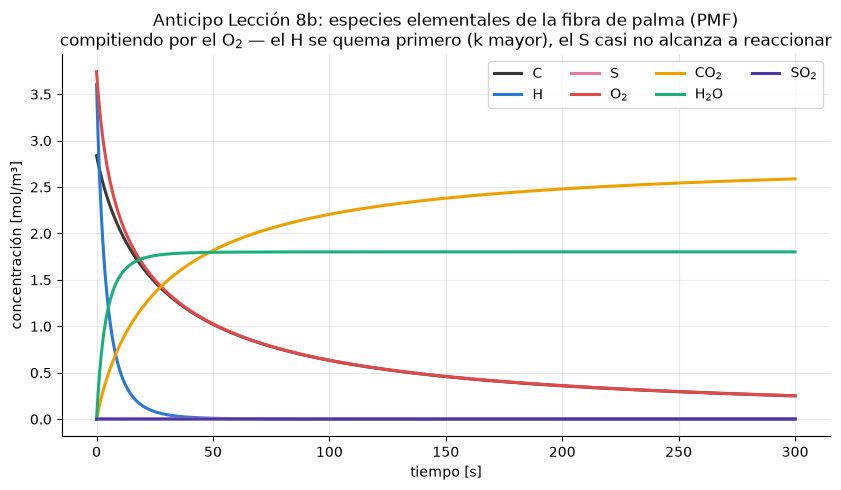

In [10]:
# ANTICIPO — combustión de la fibra de palma (PMF) con el enfoque elemental del paper
# Especies elementales C, H, S compitiendo por el O2 (jerarquía de reactividad: k_H > k_C > k_S)
C0 = {"C": 2.8383, "H": 3.6030, "S": 0.0047, "O2": 3.7423}     # mol/m³ (paper, Tabla PMF)
kC, kH, kS = 1.2e-2, 7.0e-2, 2.4e-3    # jerarquía cualitativa (kH mayor: el H se quema primero), escala didáctica

def deriv_pmf(yv, t):
    Cc, H, S, O2, CO2, H2O, SO2 = yv
    rC, rH, rS = kC*Cc*O2, kH*H*O2, kS*S*O2
    return (-rC, -rH, -rS, -(rC + rH/4 + rS), rC, rH/2, rS)

t = np.linspace(0, 300, 900)
sol = odeint(deriv_pmf, [C0["C"], C0["H"], C0["S"], C0["O2"], 0, 0, 0], t).T
nombres = ["C", "H", "S", "O$_2$", "CO$_2$", "H$_2$O", "SO$_2$"]
colores = [COL["tinta"], COL["fuel"], "#e87ba4", COL["O2"], COL["CO2"], COL["H2O"], COL["SO2"]]
fig, ax = plt.subplots(figsize=(8.5, 5))
for serie, nom, c in zip(sol, nombres, colores):
    ax.plot(t, serie, lw=2.2, color=c, label=nom)
ax.set_xlabel("tiempo [s]"); ax.set_ylabel("concentración [mol/m³]")
ax.set_title("Anticipo Lección 8b: especies elementales de la fibra de palma (PMF)\n"
             "compitiendo por el O$_2$ — el H se quema primero (k mayor), el S casi no alcanza a reaccionar")
ax.legend(ncol=4); ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Conclusión

Las **EDOs acopladas** son el microscopio temporal de la combustión: el término producto $k[A][B]$ cuenta colisiones (como el contagio del SIR cuenta encuentros), los coeficientes estequiométricos garantizan que los átomos se conserven, y el acople con Arrhenius explica la ignición. Con esta gramática — un término por fenómeno, un signo por dirección — se escribe desde la oxidación del H$_2$ hasta el modelo de 15 especies del raquis de palma (Lección 8b). Los balances de la Lección 7 dicen *cuánto*; la cinética dice *cuándo y qué tan rápido* — y el diseño de cámaras de combustión necesita ambos.

---
### Referencias
- Kermack, W. O. & McKendrick, A. G. (1927). A contribution to the mathematical theory of epidemics. *Proc. R. Soc. A*, 115, 700–721.
- Westbrook, C. K. & Dryer, F. L. (1981). Simplified reaction mechanisms for the oxidation of hydrocarbon fuels in flames. *Combust. Sci. Technol.*, 27, 31–43.
- Turns, S. R. (2012). *An Introduction to Combustion*, 3ª ed. McGraw-Hill.
- Arias-Guerrero, D. A., Castillo-Hernández, M., Mayorga-Guzmán, J. D. & Bayona-Roa, C. A. *Computational Modeling of the Combustion Reaction Kinetics of the Oil Palm's EFB and Mesocarp Fiber*. Biofuels.